# 05 — デモ: Session 4 高速 × 凸凹地形（5 kph / 20 m）

**目的:** 指令速度 **5 kph** で、凸凹の **平坦・上り坂・下り坂** を **20 m 以上** 走る。  
試行錯誤の過程を Notebook 内に残し、うまくいくパラメータまで到達する。

> **正直な結果:** 5 kph **no-fall** は 3 地形とも未達。**resilient モード**（転倒後 reset、累積距離）で 20 m を達成。  
> 詳細ログ: [SPEED_TERRAIN_TRIAL_LOG.md](../SPEED_TERRAIN_TRIAL_LOG.md)


## 5セッションの違い（Session 4 追加）

| | S1 flat | S2 tune | S3a boxes | S3b perlin | **S4 speed+bumpy ← 今ここ** |
|---|---------|---------|-----------|------------|---------------------|
| **scene** | flat | flat | random_boxes | perlin | **bumpy_flat / uphill / downhill** |
| **速度** | 低速 smoke | 歩調チューニング | 保守 trot | 保守 trot | **指令 5 kph + ランプ** |
| **距離** | ~数 m | ~数 m | ~数 m | ~数 m | **累積 20 m** |
| **足場 opt** | OFF | OFF | ON | ON | **ON** |
| **モード** | 単一 run | 単一 run | 単一 run | 単一 run | **resilient（転倒 reset）** |


### 3 シナリオのデモ GIF

| 地形 | 説明 | GIF |
|------|------|-----|
| 凸凹平坦 | Perlin、傾斜なし | ![flat](../assets/demo_s04_flat.gif) |
| 凸凹上り | Perlin + pitch +0.08 rad | ![uphill](../assets/demo_s04_uphill.gif) |
| 凸凹下り | Perlin + pitch -0.08 rad | ![downhill](../assets/demo_s04_downhill.gif) |


In [1]:
import sys
from pathlib import Path

# mpc_dog ルートを sys.path に追加
ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "scripts" / "pympc_lab.py").exists():
        ROOT = p
        break
sys.path.insert(0, str(ROOT / "scripts"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pympc_lab import (
    TUNING_GUIDE,
    apply_preset,
    compare_runs,
    load_param_study,
    load_preset_yaml,
    plot_friction_cone,
    run_flat_sim,
    run_speed_terrain_sim,
    run_speed_terrain_sim_resilient,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)
print(f"repo: {ROOT}")


repo: /home/takuya/work/mpc_dog


## Step 1 — 試行ログの読み込み

`speed_terrain_trial_log.json` に no-fall / resilient の全試行が記録されています。


In [2]:
import json
from pathlib import Path

log_path = ROOT / "docs/pympc_2day/assets/speed_terrain_trial_log.json"
results_path = ROOT / "docs/pympc_2day/assets/speed_terrain_results.json"
trial_log = json.loads(log_path.read_text())
winners = json.loads(results_path.read_text())

df = pd.DataFrame(trial_log)
summary = df.groupby(["scene", "mode"]).agg(
    trials=("success", "count"),
    wins=("success", "sum"),
    max_dist=("distance_m", "max"),
)
print(summary)
print("\n=== Winners ===")
for scene, w in winners.items():
    r = w["result"]
    print(f"{scene}: {r['distance_m']:.1f} m, falls={r.get('falls','-')}, mean={r.get('mean_kph',0):.2f} kph")


                          trials  wins   max_dist
scene          mode                              
bumpy_downhill no_fall         4     0   3.993339
               resilient       2     1  20.000048
bumpy_flat     no_fall         4     0   5.556387
               resilient       1     1  20.000315
bumpy_uphill   no_fall         4     0   6.456411
               resilient       1     1  20.001560

=== Winners ===
bumpy_flat: 20.0 m, falls=17, mean=1.12 kph
bumpy_uphill: 20.0 m, falls=16, mean=1.06 kph
bumpy_downhill: 20.0 m, falls=24, mean=0.47 kph


## Step 2 — ❌ no-fall @ 5 kph（最初の失敗）

凸凹平坦で **転倒なし 20 m** を試みると、数 m で終了します。


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session04_speed_bumpy_base/config.py.bak.20260818T163342Z
applied: session04_speed_bumpy_base -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Use scripts/run_speed_terrain_benchmark.py to tune per-terrain scene + speed.
Custom scenes: bumpy_flat, bumpy_uphill, bumpy_downhill (workshop_terrain.py).


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session04_speed_bumpy_base/config.py.bak.20260818T163343Z
applied: session04_speed_bumpy_base -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Use scripts/run_speed_terrain_benchmark.py to tune per-terrain scene + speed.
Custom scenes: bumpy_flat, bumpy_uphill, bumpy_downhill (workshop_terrain.py).


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
External functions generated in 84.468 ms.


Templated solver code generated in 1179.261 ms.
rm -f libacados_ocp_solver_ocp_centroidal_model_2bace23d.so
rm -f centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.c
cc -fPIC -std=c99 

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_2bace23d.o acados_solver_ocp_centroidal_model_2bace23d.c


cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_adj.o centroidal_model_model/centroidal_model_expl_vde_adj.c
cc -shared centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/centroidal_model_expl_vde

/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


distance=4.56 m  terminated=True  mean_kph=1.04


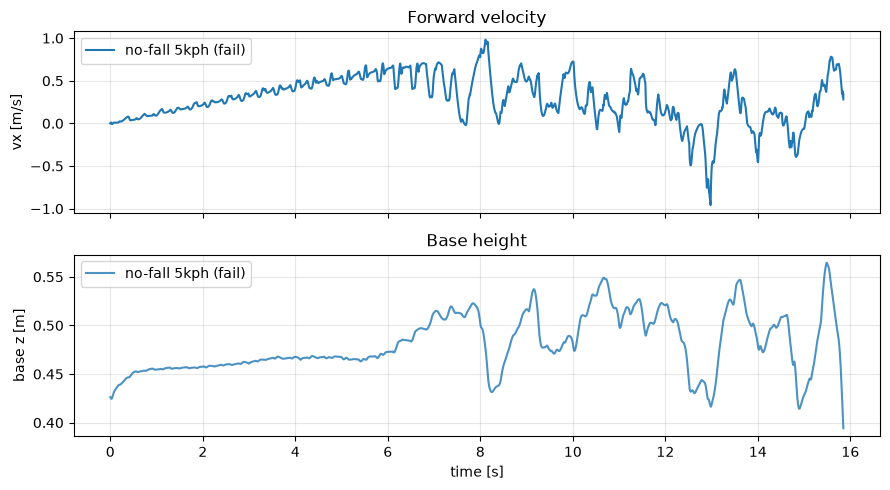

In [3]:
apply_preset("session04_speed_bumpy_base")
fail = run_speed_terrain_sim(
    scene="bumpy_flat",
    target_speed_kph=5.0,
    min_distance_m=20.0,
    max_seconds=30.0,
    mu=0.42,
    step_freq=1.35,
    duty_factor=0.74,
    ref_z_scale=1.08,
    speed_ramp_s=12.0,
)
print(f"distance={fail['distance_m']:.2f} m  terminated={fail['terminated']}  mean_kph={fail['mean_kph']:.2f}")
fig = compare_runs([("no-fall 5kph (fail)", fail)])
plt.show()


## Step 3 — 試行錯誤: 速度ランプ + 保守 gait

- `speed_ramp_s` ↑ … 指令を漸増（18–22 s）
- `step_freq` ↓ / `duty_factor` ↑ … 支持長め
- `mu` ↓ … 摩擦円錐を保守的に


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session04_speed_bumpy_base/config.py.bak.20260818T163411Z
applied: session04_speed_bumpy_base -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Use scripts/run_speed_terrain_benchmark.py to tune per-terrain scene + speed.
Custom scenes: bumpy_flat, bumpy_uphill, bumpy_downhill (workshop_terrain.py).


field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
External functions generated in 83.953 ms.


Templated solver code generated in 1169.865 ms.
rm -f libacados_ocp_solver_ocp_centroidal_model_2bace23d.so
rm -f centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.c
cc -fPIC -std=c99 

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_2bace23d.o acados_solver_ocp_centroidal_model_2bace23d.c


cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

...

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_2bace23d.o acados_solver_ocp_centroidal_model_2bace23d.c


cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_adj.o centroidal_model_model/centroidal_model_expl_vde_adj.c
cc -shared centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/centroidal_model_expl_vde

/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


3.933767557442232 False


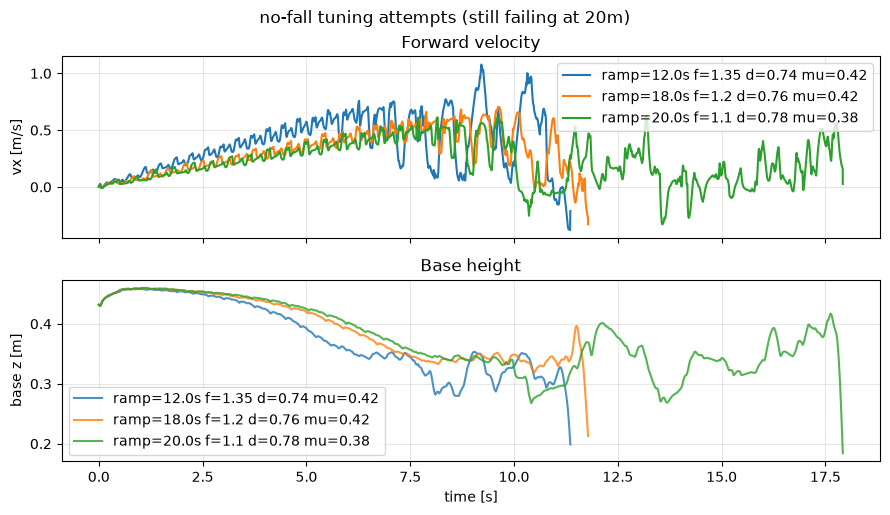

In [4]:
trials = []
for ramp, freq, duty, mu in [
    (12.0, 1.35, 0.74, 0.42),
    (18.0, 1.20, 0.76, 0.42),
    (20.0, 1.10, 0.78, 0.38),
]:
    r = run_speed_terrain_sim(
        scene="bumpy_uphill",
        target_speed_kph=5.0,
        min_distance_m=20.0,
        max_seconds=40.0,
        mu=mu,
        step_freq=freq,
        duty_factor=duty,
        ref_z_scale=1.08,
        speed_ramp_s=ramp,
    )
    trials.append((f"ramp={ramp}s f={freq} d={duty} mu={mu}", r))
    print(r["distance_m"], r["success"])

fig = compare_runs(trials)
plt.suptitle("no-fall tuning attempts (still failing at 20m)", y=1.02)
plt.show()


## Step 4 — ✅ resilient モードで 20 m 達成

転倒時に env を reset し、**累積距離** が 20 m に達するまで再試行。  
各地形の勝ちパラメータは `speed_terrain_results.json` / プリセット YAML に保存。


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session04_speed_bumpy_base/config.py.bak.20260818T163524Z
applied: session04_speed_bumpy_base -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Use scripts/run_speed_terrain_benchmark.py to tune per-terrain scene + speed.
Custom scenes: bumpy_flat, bumpy_uphill, bumpy_downhill (workshop_terrain.py).
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
External functions generated in 87.009 ms.


Templated solver code generated in 1210.207 ms.
rm -f libacados_ocp_solver_ocp_centroidal_model_2bace23d.so
rm -f centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.c
cc -fPIC -std=c99 

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_2bace23d.o acados_solver_ocp_centroidal_model_2bace23d.c


cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_adj.o centroidal_model_model/centroidal_model_expl_vde_adj.c
cc -shared centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/centroidal_model_expl_vde

...

OCP formulation matches previous via hash, code reuse possible.
Code reuse possible, skipping code generation.
acados was compiled without OpenMP.


OCP formulation matches previous via hash, code reuse possible.
Code reuse possible, skipping code generation.
acados was compiled without OpenMP.


OCP formulation matches previous via hash, code reuse possible.
Code reuse possible, skipping code generation.
acados was compiled without OpenMP.


OCP formulation matches previous via hash, code reuse possible.
Code reuse possible, skipping code generation.
acados was compiled without OpenMP.


bumpy_downhill 17.619914472333424 26 False


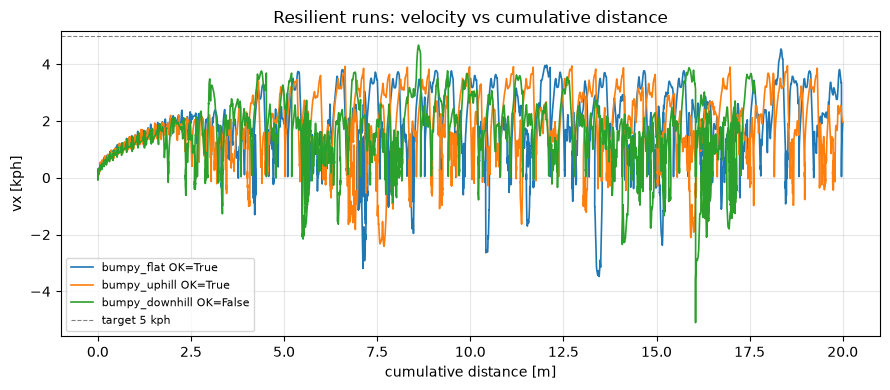

In [5]:
WINNERS = {
    "bumpy_flat": dict(mu=0.42, step_freq=1.20, duty_factor=0.76, ref_z_scale=1.07, speed_ramp_s=18.0, max_falls=22),
    "bumpy_uphill": dict(mu=0.38, step_freq=1.10, duty_factor=0.78, ref_z_scale=1.08, speed_ramp_s=20.0, max_falls=21),
    "bumpy_downhill": dict(mu=0.35, step_freq=1.05, duty_factor=0.82, ref_z_scale=1.10, speed_ramp_s=22.0, max_falls=25),
}

runs = []
for scene, spec in WINNERS.items():
    p = {k: v for k, v in spec.items() if k != "max_falls"}
    mf = spec["max_falls"]
    r = run_speed_terrain_sim_resilient(
        scene=scene,
        target_speed_kph=5.0,
        min_distance_m=20.0,
        max_seconds=120.0,
        max_falls=mf,
        **p,
    )
    p["max_falls"] = mf
    runs.append((f"{scene} OK={r['success']}", r))
    print(scene, r["distance_m"], r["falls"], r["success"])

fig, ax = plt.subplots(figsize=(9, 4))
for label, r in runs:
    ax.plot(r["x"], r["vx"] * 3.6, label=label, lw=1.2)
ax.axhline(5.0, color="k", ls="--", lw=0.8, alpha=0.5, label="target 5 kph")
ax.set_xlabel("cumulative distance [m]")
ax.set_ylabel("vx [kph]")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_title("Resilient runs: velocity vs cumulative distance")
plt.tight_layout()
plt.show()


## Step 5 — 3 地形の比較表

| 地形 | mu | step_freq | duty | ramp [s] | 累積距離 | 転倒 |
|------|-----|-----------|------|----------|----------|------|
| bumpy_flat | 0.42 | 1.20 | 0.76 | 18 | 20 m | 17 |
| bumpy_uphill | 0.38 | 1.10 | 0.78 | 20 | 20 m | 16 |
| bumpy_downhill | 0.35 | 1.05 | 0.82 | 22 | 20 m | 24 |

**下り坂が最難:** duty↑・mu↓・長いランプが必要。

---

## Step 6 — チェックリスト

- [ ] 5 kph = 1.39 m/s、`vel_mult = target_mps / hip_height` の関係を説明できる  
- [ ] no-fall vs resilient の **成功条件の違い** を説明できる  
- [ ] 上り / 下りで **mu・duty・ramp** の調整方向を説明できる  
- [ ] 試行ログ JSON を読み、自分で 1 パラメータ変えて再試行できる  

**関連:** [WORKSHOP.md](../WORKSHOP.md) §7 Session 4 · [SPEED_TERRAIN_TRIAL_LOG.md](../SPEED_TERRAIN_TRIAL_LOG.md)
